<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day09_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 9 Lab: KNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

file_link = 'https://drive.google.com/uc?export=download&id=1872WZovmmIRvyAra5AENBfUuVetA77ag'
df = pd.read_csv(file_link)
df.head()

,ID,Textbook,Videos,Lecture,Discussion,Problems,Proactive,CodeExperience,MotivatedByFun,MotivatedByChallenge,MotivatedByGrades,MotivatedByJob,Grade
0,1,3,4,3,1,2,4,1,4,3,4,4,D
1,2,2,3,5,4,3,5,1,4,4,4,4,B
2,3,4,5,5,3,5,3,1,5,4,5,5,C
3,4,1,5,3,4,3,1,1,4,3,1,3,F
4,5,4,3,3,2,2,4,2,5,4,5,5,B


Divide your data into X and y, and training and test sets.

In [2]:
# Our target variable (also known as label or y) will be Grade.
y = df['Grade']

# Our features (X) will include all the columns except ID, which is irrelevant, and Grade (11 columns total). (Remember that if you use df.drop to drop columns,
# it returns a copy of the dataframe without those columns.)
X = df.drop(['Grade', 'ID'], axis=1)

In [3]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=13)

# For KNN, it’s especially important to make sure that your data is normalized.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

Build (fit) a KNN classifier, following the slides.

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k = 41
met = 'manhattan'
model = KNeighborsClassifier(n_neighbors=k, metric=met)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
acc = accuracy_score(ytest, ypred)
print(f'For k = {k}, dist = {met}, accuracy = {acc:.2f}')

For k = 41, dist = manhattan, accuracy = 0.14


Test out your KNN classifier for a few different values of K, the number of nearest neighbors and pick the one that gives you the best accuracy. You can also compare euclidean and manhattan distances.

In [5]:
# Write a for-loop to try out a wide range of K values and report the accuracy.
min = 1
max = 41

kvals = np.arange(min, max+1)
accvals_manhattan = []
accvals_euclidean = []

for k in range(min, max+1):
    met = 'manhattan'
    model = KNeighborsClassifier(n_neighbors=k, metric=met)
    model.fit(Xtrain, ytrain)
    ypred = model.predict(Xtest)
    acc = accuracy_score(ytest, ypred)
    accvals_manhattan.append(acc)
    print(f'For k = {k}, dist = {met}, accuracy = {acc:.2f}')

    met = 'euclidean'
    model = KNeighborsClassifier(n_neighbors=k, metric=met)
    model.fit(Xtrain, ytrain)
    ypred = model.predict(Xtest)
    acc = accuracy_score(ytest, ypred)
    accvals_euclidean.append(acc)
    print(f'For k = {k}, dist = {met}, accuracy = {acc:.2f}')


For k = 1, dist = manhattan, accuracy = 0.36
For k = 1, dist = euclidean, accuracy = 0.36
For k = 2, dist = manhattan, accuracy = 0.57
For k = 2, dist = euclidean, accuracy = 0.43
For k = 3, dist = manhattan, accuracy = 0.29
For k = 3, dist = euclidean, accuracy = 0.21
For k = 4, dist = manhattan, accuracy = 0.29
For k = 4, dist = euclidean, accuracy = 0.36
For k = 5, dist = manhattan, accuracy = 0.43
For k = 5, dist = euclidean, accuracy = 0.21
For k = 6, dist = manhattan, accuracy = 0.29
For k = 6, dist = euclidean, accuracy = 0.36
For k = 7, dist = manhattan, accuracy = 0.36
For k = 7, dist = euclidean, accuracy = 0.21
For k = 8, dist = manhattan, accuracy = 0.29
For k = 8, dist = euclidean, accuracy = 0.29
For k = 9, dist = manhattan, accuracy = 0.21
For k = 9, dist = euclidean, accuracy = 0.21
For k = 10, dist = manhattan, accuracy = 0.21
For k = 10, dist = euclidean, accuracy = 0.36
For k = 11, dist = manhattan, accuracy = 0.21
For k = 11, dist = euclidean, accuracy = 0.29
For k 

## Challenge: make a plot

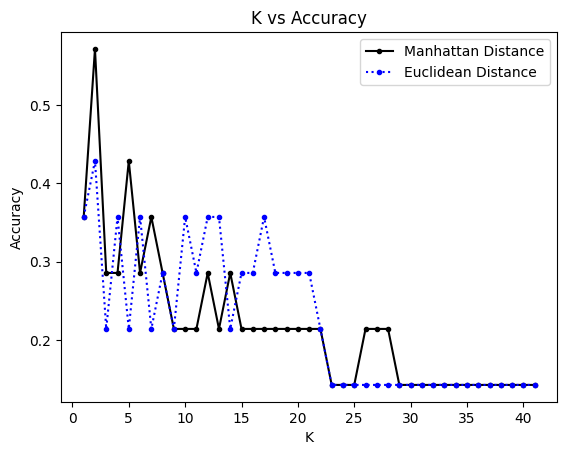

In [6]:
plt.plot(kvals, accvals_manhattan, '.-k', label='Manhattan Distance')
plt.plot(kvals, accvals_euclidean, '.:b', label='Euclidean Distance')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.legend();

Pick the best hyperparameters from our experiments

In [7]:
k = 2
met = 'manhattan'
model = KNeighborsClassifier(n_neighbors=k, metric=met)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
acc = accuracy_score(ytest, ypred)
print(f'For k = {k}, dist = {met}, accuracy = {acc:.2f}')

For k = 2, dist = manhattan, accuracy = 0.57


## Confusion matrix

[[1 0 0 0 0]
 [0 4 3 0 0]
 [0 0 2 0 0]
 [0 0 2 1 0]
 [0 1 0 0 0]]


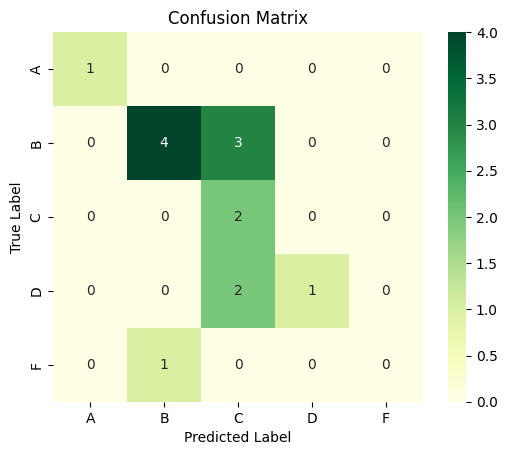

In [8]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, ypred)
print(cm)

# Confusion matrix works better with color
import seaborn as sns
cm_labels = np.sort(ytrain.unique())
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                    cmap='YlGn',
                    xticklabels=cm_labels,
                    yticklabels=cm_labels)

plt.xlabel('Predicted Label');
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Challenge: regression
Possibly we could do better with regression instead of classification because the categories we want to predict are ordinal. Try converting Grade to be numeric, mapping A to 4, B to 3, C to 2, D to 1, and F to 0. Switch your model from KNN classification to KNN regression. (Note that you’ll need to make sure your ytrain and ytest variables have the numeric values instead of the strings.) Experiment with different K values and report your lowest error (not accuracy), e.g., MAE or MSE. Here’s code to get you started:

In [9]:
# Convert grade to be numeric
ord_map = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'F': 0
}

y = y.map(ord_map)
y.head()

,Grade
0,1
1,3
2,2
3,0
4,3


In [10]:
# After converting y, we need to get the train and test sets again
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=13)

# Normalize
Xmin = Xtrain.min(axis=0)
Xmax = Xtrain.max(axis=0)
Xtrain = (Xtrain - Xmin) / (Xmax - Xmin)
Xtest = (Xtest - Xmin) / (Xmax - Xmin)

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

kvals = np.arange(1, 42)
mae_list_manhattan = []
mae_list_euclidean = []

for k in kvals:
    model = KNeighborsRegressor(n_neighbors=k, metric='manhattan')
    model.fit(Xtrain, ytrain)

    ypred = model.predict(Xtest)
    mae = mean_absolute_error(ytest, ypred)
    mae_list_manhattan.append(mae)

    model = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    model.fit(Xtrain, ytrain)

    ypred = model.predict(Xtest)
    mae = mean_absolute_error(ytest, ypred)
    mae_list_euclidean.append(mae)


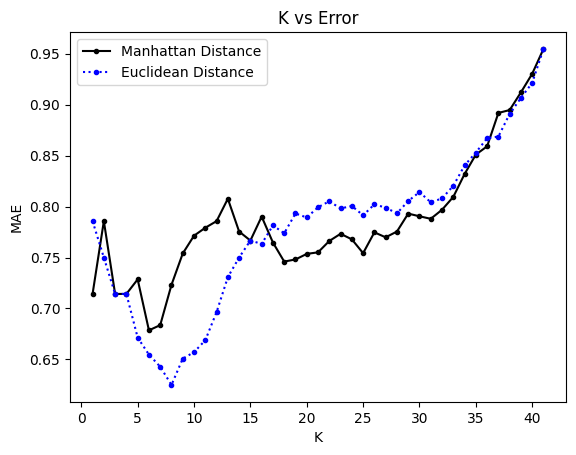

In [12]:
plt.plot(kvals, mae_list_manhattan, '.-k', label='Manhattan Distance')
plt.plot(kvals, mae_list_euclidean, '.:b', label='Euclidean Distance')
plt.xlabel('K')
plt.ylabel('MAE')
plt.title('K vs Error')
plt.legend();